# Mosaic integration

Mosaic integration combines batches that share only some modalities. For example, a paired RNA + ATAC batch can link an RNA-only batch and an ATAC-only batch. Each method accepts one batch pattern, and every mosaic method reads ATAC as peaks. This tutorial uses `D45`, with 32,151 cells in three batches.

## 1. Install

The first cell installs `multibench-sc`. Methods run only on Linux, each in its own environment. Set `INSTALL_ENVS = True` on Linux or Colab to download the environments. On macOS and Windows every cell still runs and uses stored outputs instead.

<details>
<summary>Details</summary>

With `INSTALL_ENVS = False`, the notebook downloads only the reference data and the stored outputs. A method cell then prints one line and loads those outputs.

With `INSTALL_ENVS = True`, the cells download prebuilt environments and run the methods, with no conda needed.

On Colab, choose a GPU runtime first: Runtime -> Change runtime type -> T4 GPU. On a CPU runtime, training methods are much slower.

</details>

In [1]:
import importlib.metadata, importlib.util, sys
if importlib.util.find_spec("multibench") is None:
    # keep the numpy / pandas this interpreter already has
    pins = [f"{p}=={importlib.metadata.version(p)}" for p in ("numpy", "pandas") if importlib.util.find_spec(p)]
    !{sys.executable} -m pip -q install "multibench-sc>=0.3.2" {" ".join(pins)}
    importlib.invalidate_caches()
    # not on PyPI yet: install from GitHub
    if importlib.util.find_spec("multibench") is None:
        !{sys.executable} -m pip -q install "git+https://github.com/DSichang/scMultiBench.git" {" ".join(pins)}
else:
    print("multibench already installed")

multibench already installed


In [2]:
# False: no environment is downloaded; method cells use stored outputs.
# True (Linux or Colab): run the methods here; no conda needed.
# 2 envs, 1.8 GB to download on a CPU host, 5.5 GB on a GPU host.
INSTALL_ENVS = False

In [3]:
%matplotlib inline
import warnings
from pathlib import Path
import anndata
import pandas as pd
from tqdm import TqdmWarning
# hide library warnings; the warnings of multibench stay visible
for _w in (FutureWarning, DeprecationWarning, pd.errors.PerformanceWarning,
           anndata.ImplicitModificationWarning, TqdmWarning):
    warnings.filterwarnings("ignore", category=_w)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
import multibench as mtb

DATASET  = "D45"
CATEGORY = "mosaic"
# the reference data (290 MB + 97 MB), downloaded once
mtb.data.fetch('D45', 'D46')
print("multibench", mtb.__version__)

multibench 0.3.2


## 2. Run the analysis

### Environments: only if you will run methods

The next cell installs the environments for StabMap and scMoMaT: 2 envs, 1.8 GB to download on a CPU host, 5.5 GB on a GPU host. It downloads nothing unless `INSTALL_ENVS = True` and the computer runs Linux.

<details>
<summary>Details</summary>

Environments are unpacked under `mtb.config.DEFAULT.envs_dir`. Set it before this cell to use another disk. Without conda on the computer, the default is `~/.cache/multibench/envs`. An environment that is already there is not downloaded again.

To install every mosaic environment from a terminal, run `multibench env install --category mosaic --packed --run`. That is 6 envs, 15.6 GB to download on a CPU host, 20.8 GB on a GPU host. `multibench env plan --category mosaic` lists the size of each.

</details>

In [4]:
import sys
if not INSTALL_ENVS:
    print("INSTALL_ENVS is False: no environment is downloaded")
elif sys.platform != "linux":
    print("method environments run only on Linux: skipped on", sys.platform)
else:
    # dry run: sizes only
    plan = mtb.env.install(['StabMap', 'scMoMaT'], category=CATEGORY)
    todo = [r for r in plan if not r["exists"]]
    print(f"{len(todo)} of {len(plan)} envs to download, {sum(r['archive_bytes'] or 0 for r in todo) / 1e9:.1f} GB")
    for r in mtb.env.install(['StabMap', 'scMoMaT'], category=CATEGORY, packed=True, dry_run=False):
        print(f"{r['env']:20s} {r['state']}")

INSTALL_ENVS is False: no environment is downloaded


### Run the methods

`run_all` runs StabMap and scMoMaT on `D46`, each in its own environment. Each method writes an embedding. An embedding is a table of numbers with one row per cell. `run_all` scores each embedding with the scIB metrics. Without environments, the cell prints one line and loads stored outputs instead.

<details>
<summary>Details</summary>

The stored outputs are the `run_all` outputs for `D46` from the benchmark's Linux machine. `mtb.data.fetch_outputs` downloads them and `mtb.load_batch` reloads them, so the embeddings and run times are real.

If that download fails, the cell uses the stored metric table (`load_results(source="rerun")`) instead. The `status` column then reads `STORED`, and there is no embedding to score.

These methods run on `D46`, whose batch pattern they accept. The stored metric table has no `D46` results, so it shows `D45` instead.

</details>

In [5]:
def stored_sweep(dataset, methods=None):
    """The stored results for `dataset`, as the object `run_all` returns."""
    long = mtb.load_results(CATEGORY, dataset=dataset, source="rerun", methods=methods)
    recs = [{"method": m, "status": "STORED", "metrics": g.set_index("metric")["value"].to_dict()}
            for m, g in long.groupby("method")]
    return mtb.BatchResult(recs, dataset, CATEGORY)

def replacement(dataset, methods, stored):
    """The run_all outputs for `dataset` from the benchmark's Linux machine; the stored results if that download fails."""
    try:
        res = mtb.load_batch(mtb.data.fetch_outputs(dataset), methods=methods)
        print(f"replacement: the run_all outputs for {dataset} from the benchmark's Linux machine, with embeddings and run times")
        return res
    # offline, or the outputs are not published yet
    except Exception as e:
        print(f"replacement: the package's stored metric table. {type(e).__name__} from fetch_outputs: {e}")
        return stored_sweep(*stored)

check = mtb.scan("D46", CATEGORY, methods=['StabMap', 'scMoMaT'])
if check.env_ok.any():
    res = mtb.run_all("D46", CATEGORY,
                      methods=['StabMap', 'scMoMaT'],
                      out_dir="/tmp/tutorial_mosaic")
else:
    print("no method environment on this computer: the run is skipped, and outputs computed elsewhere replace it")
    res = replacement("D46", ['StabMap', 'scMoMaT'], stored=("D45",))
res.summary

[scan] 2 of 2 methods have their input files. 0 of 2 have their environment installed. Method environments run only on Linux. On this computer you can check files, score embeddings and plot. The commands use this computer's paths, so run scan again on the Linux machine.


no method environment on this computer: the run is skipped, and outputs computed elsewhere replace it
replacement: the run_all outputs for D46 from the benchmark's Linux machine, with embeddings and run times


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note,caveat,reason
0,StabMap,CHAIN_OK,85.1,embedding,"[21416, 50]",0,cty1.csv+cty2.csv+cty3.csv,0.5517,file_of_origin,3,0.5740,0.7291,0.5426,0.5313,0.4882,0.9944,0.8100,0.9545,0.0273,None,NaN,
1,scMoMaT,CHAIN_OK_GRAPH_METHOD,213.5,graph,"[21416, 2]",0,cty1.csv+cty2.csv+cty3.csv,0.8356,file_of_origin,3,0.2817,0.5446,0.4152,0.3471,0.3415,0.9882,0.4944,0.4239,0.1250,None,NaN,


### Score one embedding

`run_all` has already scored every method. To score one embedding yourself, pass the file the method wrote and the dataset's label files to `mtb.evaluate`:

<details>
<summary>Details</summary>

`label_order=` gives the order in which the method stacked its cells. The cell takes it from the run record's `labels_used`.

`metrics=` selects what is computed:

- `None` (the default): every applicable metric
- `"clustering"`, `"batch"` or `"all"`: a family
- a list such as `["ARI", "NMI"]`: those metrics

Batch metrics need `batch=` or several label files.

The default Leiden backend is igraph. To compare your scores with the stored tables, set `mtb.config.DEFAULT.leiden_flavor = "leidenalg"` before `evaluate`. The two backends can move ARI by up to about 0.1.

</details>

In [6]:
m, emb = "StabMap", None
if res.out_dir is not None:
    emb = Path(res.out_dir) / f"{m}_{res.dataset}" / "embedding.h5"
if emb is None or not emb.is_file():
    print(f"no embedding on this computer for {m}: nothing to score")
    scores = None
else:
    rec = next(r for r in res.results if r["method"] == m)
    # the label files in the order the method stacked its cells
    order = [Path(f).stem for f in rec.get("labels_used") or []] or None
    scores = mtb.evaluate(emb, labels=mtb.labels_for(res.dataset), label_order=order, verbose=False)
scores.T if scores is not None else None

,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI
Value,0.579138,0.737524,0.542599,0.531259,0.486733,0.994458,0.809971,0.955694,0.027619


### Plot

`res.plot()` draws a bubble table. Circle size shows the rank within a column. Bigger is better. The fill compares the value with the other rows in the same column: the lightest fill is the lowest value in this figure, not zero.

<details>
<summary>Details</summary>

Metrics are grouped by family: blue for dimension reduction and clustering, green for batch correction. Each family starts with an `Overall` bar. Its length and colour both show the family score.

A column whose rows all hold the same value is drawn grey, and the note under the figure names it. A figure of one method is grey everywhere.

</details>

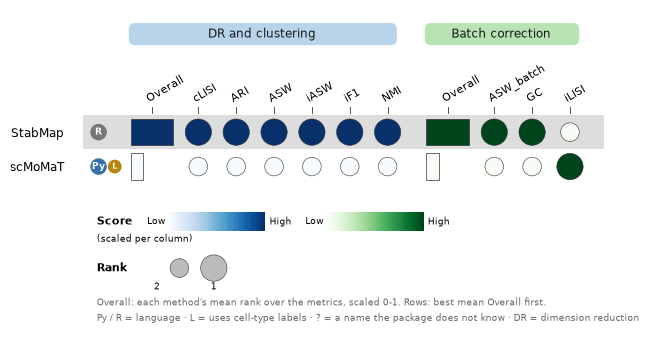

In [7]:
res.plot()

## 3. Your own data

The same calls work on a folder of your own data. Give raw counts for every modality, as in the demo data. The methods normalise the data themselves. `describe_layout` prints the files a mosaic dataset needs:

In [8]:
print(mtb.describe_layout(CATEGORY))

Put the files of one dataset in one folder: <data_path>/<DATASET>/, for example ./data/MYDATA/.
The dataset name is the folder name. data_path is the folder that contains it.

mosaic: Several batches where only some share a modality. A paired batch bridges the others.
  One numbered file per batch and modality (rna1.h5, rna2.h5, adt2.h5, adt3.h5 ...)
  and one label file per batch (cty1.csv, cty2.csv ...), in the same folder.
Each method accepts one batch pattern. Number your batches to match one of them:
  batch 1 = rna, 2 = rna+adt, 3 = adt: Multigrate
  batch 1 = rna, 2 = rna+atac, 3 = atac: Multigrate, MultiVI, Cobolt, SMILE (demo D45)
  batch 1 = rna+adt, 2 = rna+atac, 3 = rna: scMoMaT, StabMap (demo D46)
Write one file per batch, numbered to match the pattern:
  multibench convert batch1.h5ad data/MYDATA --rna X --adt obsm:protein --labels obs:cell_type --category mosaic --batch-index 1
  multibench convert batch2.h5mu data/MYDATA --rna mod:rna --atac mod:atac --atac-kind peak --

`labels_for` returns a dataset's label files: `cty1`, `cty2`, ... in that order. Some methods stack their cells in another order. `labels_for(DATASET, CATEGORY, method)` returns the files in that method's order. A wrong order gives wrong scores without an error.

<details>
<summary>Details: label order</summary>

On `D45`, `labels_for` returns another order for MultiVI (`cty1, cty3, cty2`) and SMILE (`cty2, cty1, cty3`).

Pass the dict that `labels_for` returns to `evaluate` unchanged. A dict you build or reorder yourself must be in the default order. For any other order, name the keys with `label_order=`.

`run_all` scores every order that fits the cell count and keeps the one with the highest ARI. The `label_order` column of `res.summary` shows the order it kept.

</details>

In [9]:
labels = mtb.labels_for(DATASET)            # {file stem: path}
print({k: Path(v).name for k, v in labels.items()})
print(*Path(next(iter(labels.values()))).read_text().splitlines()[:4], sep="\n")
print("MultiVI:", list(mtb.labels_for(DATASET, CATEGORY, "MultiVI")))

{'cty1': 'cty1.csv', 'cty2': 'cty2.csv', 'cty3': 'cty3.csv'}
"x"
"CD4 Naive"
"CD4 Memory"
"CD4 Naive"
MultiVI: ['cty1', 'cty3', 'cty2']


A mosaic project often arrives as one file per batch. `mtb.io.export_dataset` with `batch_index=` writes one batch per call. Number the batches to match a pattern that `describe_layout` lists. The ATAC matrix must hold peaks. Here on synthetic data with `D46`'s pattern:

<details>
<summary>Details: export</summary>

The command line writes one batch per call with `multibench convert ... --category mosaic --batch-index N`. `describe_layout` above prints the commands for `D46`'s pattern.

A call that would replace a file already in the folder raises `FileExistsError`. Pass `overwrite=True` to replace it.

</details>

In [10]:
import anndata as ad, numpy as np, tempfile, os
rng = np.random.default_rng(0)
def batch(n):
    a = ad.AnnData(X=rng.poisson(1.0, size=(n, 40)).astype(float))
    a.var_names = [f"gene{i}" for i in range(40)]
    a.obs["celltype"] = rng.choice(["T", "B", "NK"], n)
    return a
# batch 1: RNA + ADT, batch 2: RNA + ATAC peaks, batch 3: RNA only
b1, b2, b3 = batch(100), batch(80), batch(60)
b1.obsm["protein"] = rng.poisson(3.0, size=(100, 12)).astype(float)
b1.uns["protein_names"] = [f"CD{i}" for i in range(12)]
b2.obsm["peaks"] = rng.poisson(0.3, size=(80, 50)).astype(float)
b2.uns["peaks_names"] = [f"chr1:{100 * i}-{100 * i + 50}" for i in range(50)]

folder = os.path.join(tempfile.mkdtemp(), "MYMOSAIC")
kw = dict(labels="obs:celltype", category="mosaic")
mtb.io.export_dataset(b1, folder, adt="obsm:protein", batch_index=1, **kw)
mtb.io.export_dataset(b2, folder, atac="obsm:peaks", atac_kind="peak", batch_index=2, **kw)
mtb.io.export_dataset(b3, folder, batch_index=3, **kw)
print(sorted(os.listdir(folder)))
sc = mtb.scan("MYMOSAIC", CATEGORY, data_path=os.path.dirname(folder))
# the batch pattern decides which methods fit
sc[["method", "modalities", "files_ok"]]

['adt1.h5', 'atac2.h5', 'cty1.csv', 'cty2.csv', 'cty3.csv', 'rna1.h5', 'rna2.h5', 'rna3.h5']
[scan] 2 of 7 rows have their input files. 0 of 7 have their environment installed. Method environments run only on Linux. On this computer you can check files, score embeddings and plot. The commands use this computer's paths, so run scan again on the Linux machine.


,method,modalities,files_ok
0,Cobolt,rna1+rna2+atac2+atac3,False
1,MultiVI,rna1+atac3+rna2+atac2,False
2,Multigrate,rna1+rna2+adt2+adt3,False
3,Multigrate,rna1+rna2+atac2+atac3,False
4,SMILE,rna2+atac2+rna1+atac3,False
5,StabMap,rna1+rna2+rna3+adt1+atac2,True
6,scMoMaT,rna1+rna2+rna3+adt1+atac2,True


Next, a real dataset under a new name: a random 60% of `D46`'s cells, with at most 2,000 cells and 5,000 features per file.

<details>
<summary>Details: cell alignment</summary>

Files with the same number of cells keep the same cells in the same order. Each modality file then stays aligned with its label file. An export of your own data must keep this alignment too.

</details>

In [11]:
import os
import h5py
import numpy as np
import pandas as pd

def subsample_dataset(src_dir, dst_dir, frac=0.6, seed=0, max_cells=2000, max_features=5000):
    """Copy a dataset under a new name, keeping a random `frac` of its cells; files with the same cell count keep the same cells."""
    rng = np.random.default_rng(seed)
    os.makedirs(dst_dir, exist_ok=True)
    counts, keep = {}, {}
    for fn in sorted(os.listdir(src_dir)):
        p = os.path.join(src_dir, fn)
        if fn.endswith(".h5"):
            with h5py.File(p) as f:
                if "matrix/data" in f:
                    # matrix/data is features x cells
                    counts[fn] = f["matrix/data"].shape[1]
        elif fn.endswith(".csv"):
            counts[fn] = len(pd.read_csv(p))
    for n in set(counts.values()):
        k = min(max(50, int(n * frac)), max_cells)
        keep[n] = np.sort(rng.choice(n, size=k, replace=False))
    for fn, n in counts.items():
        sp, dp = os.path.join(src_dir, fn), os.path.join(dst_dir, fn)
        idx = keep[n]
        if fn.endswith(".csv"):
            pd.read_csv(sp).iloc[idx].to_csv(dp, index=False)
        else:
            with h5py.File(sp) as f, h5py.File(dp, "w") as g:
                grp = g.create_group("matrix")
                n_feat = f["matrix/data"].shape[0]
                fidx = np.arange(n_feat) if n_feat <= max_features else np.sort(rng.choice(n_feat, size=max_features, replace=False))
                block = f["matrix/data"][fidx, :] if n_feat > max_features else f["matrix/data"][()]
                grp.create_dataset("data", data=np.asarray(block)[:, idx])
                if "matrix/features" in f:
                    grp.create_dataset("features", data=np.asarray(f["matrix/features"])[fidx])
                if "matrix/barcodes" in f:
                    grp.create_dataset("barcodes", data=np.asarray(f["matrix/barcodes"])[idx])
    return dst_dir

`scan` checks each method variant. A variant is one set of input files that a method accepts. `files_ok` checks the folder and works on any computer. `env_ok` checks the environment. A variant is `runnable` only when both pass and its ATAC file holds the form the method reads. `reason` says what failed.

In [12]:
DATA_ROOT = "/tmp/mydata"
src = mtb.config.DEFAULT.data_path / "D46"
subsample_dataset(src, f"{DATA_ROOT}/MYDATA_mosaic", frac=0.6)

sc = mtb.scan(f"MYDATA_mosaic", category=CATEGORY, data_path=DATA_ROOT)
print(f"runnable: {int(sc.runnable.sum())} of {len(sc)}")
sc[["method", "modalities", "files_ok", "env_ok", "runnable", "reason"]].head(6)

[scan] 2 of 7 rows have their input files. 0 of 7 have their environment installed. Method environments run only on Linux. On this computer you can check files, score embeddings and plot. The commands use this computer's paths, so run scan again on the Linux machine.


runnable: 0 of 7


,method,modalities,files_ok,env_ok,runnable,reason
0,Cobolt,rna1+rna2+atac2+atac3,False,False,False,"Cobolt needs peak ATAC (atac3.h5), which is not in the folder. Environment scmb_cobolt3 runs only on Linux, not on this computer."
1,MultiVI,rna1+atac3+rna2+atac2,False,False,False,"MultiVI needs peak ATAC (atac3.h5), which is not in the folder. Environment scmb_multivi runs only on Linux, not on this computer."
2,Multigrate,rna1+rna2+adt2+adt3,False,False,False,"adt2.h5, adt3.h5 are missing. Environment scmb_multigrate2 runs only on Linux, not on this computer."
3,Multigrate,rna1+rna2+atac2+atac3,False,False,False,"Multigrate needs peak ATAC (atac3.h5), which is not in the folder. Environment scmb_multigrate2 runs only on Linux, not on this computer."
4,SMILE,rna2+atac2+rna1+atac3,False,False,False,"SMILE needs peak ATAC (atac3.h5), which is not in the folder. Environment env_sciPENN runs only on Linux, not on this computer. SMILE needs an NVIDIA GPU, and this computer has none. See method_info(""SMILE"")[""requires_gpu""]."
5,StabMap,rna1+rna2+rna3+adt1+atac2,True,False,False,"Environment scmb_r runs only on Linux, not on this computer."


In [13]:
if sc[sc.method.isin(['StabMap', 'scMoMaT'])].env_ok.any():
    mine = mtb.run_all(f"MYDATA_mosaic", CATEGORY,
                       methods=['StabMap', 'scMoMaT'],
                       out_dir=f"{DATA_ROOT}/out_mosaic",
                       data_path=DATA_ROOT)
else:
    print("no method environment on this computer: the run is skipped, and outputs computed elsewhere replace it")
    # the stored results for D45s, a 60% subsample of D45
    mine = stored_sweep("D45s")
mine.summary

no method environment on this computer: the run is skipped, and outputs computed elsewhere replace it


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note,caveat,reason
0,Cobolt,STORED,None,None,None,<NA>,None,NaN,None,<NA>,0.775656,0.794595,0.612229,0.641862,0.864671,0.998486,0.946694,0.976880,0.791436,not scored,NaN,
1,MultiVI,STORED,None,None,None,<NA>,None,NaN,None,<NA>,0.697393,0.744044,0.561429,0.608409,0.882976,0.997836,0.984818,0.989113,0.885277,not scored,NaN,
2,Multigrate,STORED,None,None,None,<NA>,None,NaN,None,<NA>,0.731960,0.732197,0.543329,0.544089,0.724592,0.983375,0.916007,0.942182,0.691455,not scored,NaN,
3,SMILE,STORED,None,None,None,<NA>,None,NaN,None,<NA>,0.266965,0.489926,0.533806,0.531591,0.476381,0.964706,0.940907,0.897628,0.723777,not scored,NaN,


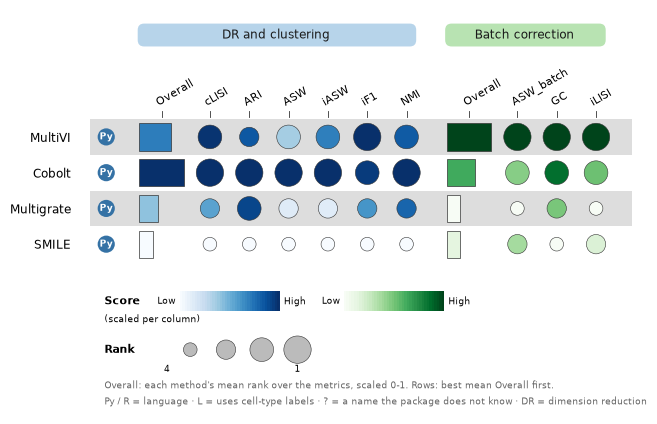

In [14]:
mine.plot()

## 4. Stored results

The package ships stored results for 4 methods on `D45`. `load_results(..., source="rerun")` reads them as a long table, and `mtb.plot.bubble` draws it. A long table has one row per method and metric. Nothing is run.

<details>
<summary>Details: sources</summary>

There are no scIB tables for mosaic under `source="published"`, the default of `load_results`. That call raises `FileNotFoundError`, so every call here names `source="rerun"`, the only stored source.

`run_all` saves its results in `out_dir`, and `mtb.load_batch(out_dir)` reloads them later without running anything. Use one `out_dir` per dataset and category: a second `run_all` into the same folder adds its methods to the saved results, and one for another dataset raises `ValueError`.

</details>

4 methods, ['rerun']


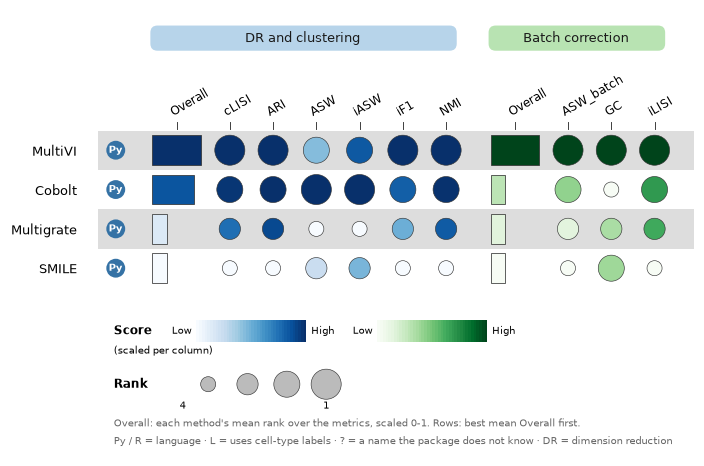

In [15]:
long = mtb.load_results(CATEGORY, dataset=DATASET, source="rerun")
print(long.method.nunique(), "methods,", long.source.unique())
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
fig

A summary compares methods scored on the same datasets. `aggregate="summary"` ranks the methods over `D45` and `D45s`, a random 60% subsample of `D45`'s cells. `require_complete=True` keeps only the methods with results on both.

<details>
<summary>Details: summary bars</summary>

Each metric bar is the method's rank averaged over the datasets, then min-max scaled. `Overall` summarises the ranks of the family's metrics. Bar length and colour both show the value.

Without `require_complete=True`, a method that is missing from one dataset gets the lowest rank there, which pulls its bars down.

`D45s` is a random subsample used for the package's second run of the methods. It cannot be downloaded or rebuilt, so a summary that includes your own method uses the full datasets only.

</details>

{'D45': 4, 'D45s': 4}


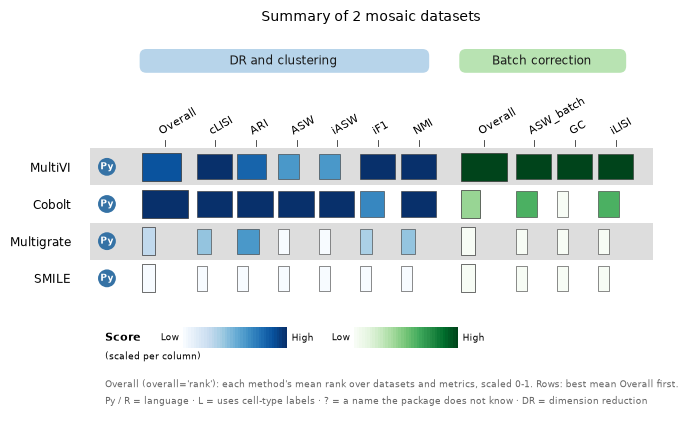

In [16]:
pair = mtb.load_results(CATEGORY, dataset=[DATASET, DATASET + "s"], source="rerun")
print(pair.groupby("dataset").method.nunique().to_dict())
mtb.plot.bubble(pair, aggregate="summary", require_complete=True,
                title=f"Summary of 2 mosaic datasets")

`results_coverage` counts the methods stored for this dataset:

In [17]:
cov = mtb.results_coverage(CATEGORY)
cov[cov.dataset == DATASET].groupby("source").method.nunique()

source
rerun    4
Name: method, dtype: int64

## 5. Reference

### What runs on a dataset, and why not

`scan` on `D45` runs nothing. The first table lists the variants whose input files are in place, and `caveat` says what to check before a run. The second table says why the other variants do not fit.

<details>
<summary>Details</summary>

For a missing environment, `env_reason` gives the install command, or says that the environment runs only on Linux.

From a terminal, `multibench scan D45 --category mosaic` prints the same scan. `--columns all` adds every column, including `command`: the exact command `run` would execute.

</details>

In [18]:
avail = mtb.scan(DATASET, category=CATEGORY)
print(f"runnable: {int(avail.runnable.sum())} of {len(avail)}")
avail[avail.files_ok][["method", "modalities", "env", "env_ok", "env_reason",
                       "output_kind", "needs_labels", "runtime_tier", "caveat"]]

[scan] 4 of 7 rows have their input files. 0 of 7 have their environment installed. Method environments run only on Linux. On this computer you can check files, score embeddings and plot. The commands use this computer's paths, so run scan again on the Linux machine.


runnable: 0 of 7


,method,modalities,env,env_ok,env_reason,output_kind,needs_labels,runtime_tier,caveat
0,Cobolt,rna1+rna2+atac2+atac3,scmb_cobolt3,False,"Environment scmb_cobolt3 runs only on Linux, not on this computer.",embedding,False,slow,
1,MultiVI,rna1+atac3+rna2+atac2,scmb_multivi,False,"Environment scmb_multivi runs only on Linux, not on this computer.",embedding,False,very_slow,
3,Multigrate,rna1+rna2+atac2+atac3,scmb_multigrate2,False,"Environment scmb_multigrate2 runs only on Linux, not on this computer.",embedding,False,very_slow,
4,SMILE,rna2+atac2+rna1+atac3,env_sciPENN,False,"Environment env_sciPENN runs only on Linux, not on this computer. SMILE needs an NVIDIA GPU, and this computer has none. See method_info(""SMILE"")[""requires_gpu""].",embedding,False,slow,


In [19]:
not_ok = avail[~avail.files_ok][["method", "modalities", "files_reason"]]
not_ok.head(5) if len(not_ok) else "(every method's inputs resolve on this dataset)"


,method,modalities,files_reason
2,Multigrate,rna1+rna2+adt2+adt3,"FileNotFoundError: Multigrate (mosaic) needs adt2.h5 and adt3.h5 in /tmp/mbc/multibench/data/D45. The folder holds atac2.h5, atac3.h5, cty1.csv, cty2.csv, cty3.csv, rna1.h5 and rna2.h5."
5,StabMap,rna1+rna2+rna3+adt1+atac2,"FileNotFoundError: StabMap (mosaic) needs rna3.h5 and adt1.h5 in /tmp/mbc/multibench/data/D45. The folder holds atac2.h5, atac3.h5, cty1.csv, cty2.csv, cty3.csv, rna1.h5 and rna2.h5."
6,scMoMaT,rna1+rna2+rna3+adt1+atac2,"FileNotFoundError: scMoMaT (mosaic) needs rna3.h5 and adt1.h5 in /tmp/mbc/multibench/data/D45. The folder holds atac2.h5, atac3.h5, cty1.csv, cty2.csv, cty3.csv, rna1.h5 and rna2.h5."


### Tuning

The table counts the parameters each variant exposes. `mtb.params_for(method, CATEGORY, modalities)` lists them, and `run_all(..., params={"Method": {"key": value}})` sets them.

<details>
<summary>Details</summary>

Many upstream scripts set their parameters in code. Their variants accept no `params`.

From a terminal, `multibench params METHOD` prints the table, and `multibench run-all ... --param METHOD:KEY=VALUE` sets a value.

</details>

In [20]:
rows = [{"method": m, "modalities": "+".join(v["modalities"]) or "(data_dir)",
         "n_tunable": v["n_tunable"], "needs_labels": v["needs_labels"],
         "output_kind": v["output_kind"]}
        for m in sorted(mtb.list_methods(category=CATEGORY))
        for v in mtb.method_info(m)["supports"] if v["category"] == CATEGORY]
pd.DataFrame(rows).sort_values(["n_tunable", "method"], ascending=[False, True]).reset_index(drop=True)

,method,modalities,n_tunable,needs_labels,output_kind
0,Cobolt,rna1+rna2+atac2+atac3,2,False,embedding
1,Multigrate,rna1+rna2+adt2+adt3,2,False,embedding
2,Multigrate,rna1+rna2+atac2+atac3,2,False,embedding
3,MultiVI,rna1+atac3+rna2+atac2,0,False,embedding
4,SMILE,rna2+atac2+rna1+atac3,0,False,embedding
5,StabMap,rna1+rna2+rna3+adt1+atac2,0,False,embedding
6,scMoMaT,rna1+rna2+rna3+adt1+atac2,0,True,graph


### A method's record and citation

`method_info` returns what the package knows about a method, including its reference and repository. `mtb.cite` returns the citations for the benchmark and for the methods you pass. The cell cites StabMap. For your own work, pass every method you ran.

<details>
<summary>Details</summary>

`needs_labels` is True when any variant of the method needs cell-type labels. Each entry of `supports` gives it per variant, together with the modalities and the output kind.

`gpu` says how the method uses a GPU: `required`, `used when present`, `not used` or `unknown`.

`verbose=True` adds the long notes.

</details>

In [21]:
info = mtb.method_info("StabMap", verbose=True)
{k: info[k] for k in ("id", "env", "needs_labels", "atac", "gpu", "notes", "repo_url", "version", "reference")}

{'id': 'StabMap',
 'env': 'scmb_r',
 'needs_labels': False,
 'atac': 'peak',
 'gpu': 'not used',
 'notes': 'Mosaic integration by stabilised mapping onto a reference embedding using shared and unshared features; R.',
 'repo_url': 'https://github.com/MarioniLab/StabMap',
 'version': '0.1.8',
 'reference': {'doi': '10.1038/s41587-023-01766-z',
  'title': 'Stabilized mosaic single-cell data integration using unshared features',
  'authors': 'Ghazanfar S, Guibentif C, Marioni JC',
  'journal': 'Nature Biotechnology',
  'year': 2024}}

In [22]:
print(mtb.cite(["StabMap"]))   # fmt="bibtex" for BibTeX entries

Liu C, Ding S, Kim HJ, Long S, Xiao D, Ghazanfar S, Yang P. Multitask benchmarking of single-cell multimodal omics integration methods. Nature Methods (2025). https://doi.org/10.1038/s41592-025-02856-3
Ghazanfar S, Guibentif C, Marioni JC. Stabilized mosaic single-cell data integration using unshared features. Nature Biotechnology (2024). https://doi.org/10.1038/s41587-023-01766-z


### The metrics

There are two families, and higher is better for every metric.

| family | metrics | measures |
|---|---|---|
| clustering / bio-conservation | `ARI`, `NMI`, `ASW`, `iASW`, `iF1`, `cLISI` | whether the embedding separates the annotated cell types |
| batch correction | `ASW_batch`, `GC`, `iLISI` (+ opt-in `kBET`) | whether the batches mix within each cell type |

<details>
<summary>Details</summary>

ARI can fall slightly below 0. About 0 means a random clustering. Every other metric lies between 0 and 1. `mtb.catalog.metrics()` describes each one.

Batch metrics appear only when the dataset has more than one batch.

kBET is computed only when named, as in `metrics=["ASW_batch", "GC", "iLISI", "kBET"]`. It is much slower than the others.

</details>

### Methods from the benchmark study

The cell compares the methods the scMultiBench study benchmarked for mosaic integration with the methods this package has a mosaic variant for. It prints each missing method with the categories it has variants for.

<details>
<summary>Details</summary>

UINMF has no mosaic variant. Its script takes the second batch's unshared features from the first batch, which fails when the two are different modalities. It also accepts exactly two batches, a pattern that fits no mosaic dataset here.

</details>

In [23]:
# benchmarked for mosaic on dimension reduction, batch correction and clustering
paper = ['MultiVI', 'scMoMaT', 'StabMap', 'Cobolt', 'UINMF', 'Multigrate', 'SMILE']
in_package = set(mtb.list_methods())
has_variant = sorted(m for m in in_package
                     if any(v["category"] == CATEGORY for v in mtb.method_info(m)["supports"]))
missing = [m for m in paper if m not in has_variant]
print(f"the study benchmarks {len(paper)} {CATEGORY} methods on dimension reduction, batch correction and clustering")
print(f"this package has a {CATEGORY} variant for {len(has_variant)}")
for m in missing:
    if m in in_package:
        print(f"  {m}: variants for {', '.join(mtb.method_info(m)['categories'])} only")
    else:
        print(f"  {m}: not in this package")
if not missing:
    print("every benchmarked method has a variant for this category")

the study benchmarks 7 mosaic methods on dimension reduction, batch correction and clustering
this package has a mosaic variant for 6
  UINMF: variants for vertical, cross only


## Troubleshooting

`scan`'s `reason` column says why a method is not runnable. `res.failures` says why a run failed or a method you named was skipped.

<details>
<summary>Details</summary>

| symptom | fix |
|---|---|
| `files_ok` False: input files not found | `reason` names the missing file |
| `env_ok` False on Linux | run the `multibench env install ...` command in `env_reason` |
| `env_ok` False on macOS or Windows | methods run only on Linux: run the same calls there |
| `env_ok` False: the method needs an NVIDIA GPU | run it on a GPU machine. On a computer without one, `mtb.scan(..., assume_gpu=True)` checks everything else |
| `FileExistsError` from `export_dataset` | the folder already holds the file: pass `overwrite=True` to replace it |
| a warning that values are not whole numbers | export raw counts, for example with `rna="layer:counts"` |
| `... matrix/data as cells x features` | the matrix is transposed: export it again with `mtb.io.export_dataset` or `mtb.io.to_canonical` |
| a method fails | `res.failures.iloc[0]["error"]` ends with the method's stderr |
| a method times out | raise `timeout=` in `run_all` |
| low `label_order_confidence` | several label files fit the cell count: check `label_order_candidates` in `res.results` |
| batch metrics use the wrong batches | `res.rescore(batch=my_vector)` scores again without running the methods |

</details>

## Next steps

- the other tutorials: vertical, diagonal, cross
- the [interactive explorer](https://shiny.maths.usyd.edu.au/scMultiBench/): the full benchmark's rankings, no install needed
- `mtb.recommend(CATEGORY, modalities=[...])`: a ranking of methods from the stored results, to read as a hint
- `mtb.sweep(...)`: one method over a range of values of one parameter